# Perfil edad-ingreso en Bogotá

GEIH 2018. Perfil cuadrático del ingreso laboral mensual de los ocupados adultos.

## 1. Marco y estimador
La acumulación de capital humano y su depreciación motivan un perfil cóncavo. La edad aproxima experiencia y también mezcla cohortes y selección al empleo; el corte transversal no identifica la trayectoria causal de una persona.
$$y_i=\log(w_i^{ingreso})=\beta_0+\beta_1 A_i+\beta_2 A_i^2+u_i.$$
Aquí $A_i$ es edad y $w_i^{ingreso}$ denota ingreso mensual; en las expresiones de ponderación, $w_i$ denota exclusivamente el factor de expansión.
Se usa $w_i=\texttt{fex\_c}_i$ para que cada registro contribuya según la cantidad de personas que representa en Bogotá, en vez de dar el mismo peso a cada fila de la muestra. El objetivo corresponde a ocupados de 18 años o más con ingreso positivo observado; los pesos no recuperan automáticamente a quienes no reportaron ingreso. La suma de pesos es una estimación de población, no el tamaño muestral empleado para los grados de libertad.

Para $X$ y $\Omega=\operatorname{diag}(w_i)$ se estima mínimos cuadrados ponderados:
$$\hat\beta_w=\arg\min_b\sum_i w_i(y_i-x_i'b)^2=(X'\Omega X)^{-1}X'\Omega y.$$
La implementación usa una factorización estable y pseudoinversa si hay columnas redundantes. Multiplicar todos los pesos por una constante no cambia el estimador. Se reporta
$$R_w^2=1-\frac{\sum_iw_i\hat u_i^2}{\sum_iw_i(y_i-\bar y_w)^2},\qquad \mathrm{RMSE}_w=\sqrt{\frac{\sum_i w_i\hat u_i^2}{\sum_iw_i}}.$$
La covarianza analítica es el sándwich HC1 ponderado, con $k=\operatorname{rango}(X)$:
$$\hat V_w=\frac{n}{n-k}(X'\Omega X)^{-1}\left(\sum_iw_i^2\hat u_i^2x_ix_i'\right)(X'\Omega X)^{-1}.$$
El factor de expansión no es un peso de precisión inversa. Por eso la inferencia principal usa HC1 y bootstrap, en lugar de atribuirle una interpretación homoscedástica al error clásico ponderado. Estas aproximaciones por personas no reproducen estratos y conglomerados del diseño completo del DANE.

### Personas representadas y precisión del total
Para el conjunto de registros $G$ utilizado en cada estimación se reportan dos cantidades distintas:
$$n_G=\sum_{i\in G}1,\qquad \widehat N_G=\sum_{i\in G}\texttt{fex\_c}_i.$$
$n_G$ cuenta observaciones y $\widehat N_G$ estima las personas representadas en la escala del archivo. Se suman los factores originales, sin normalizarlos a media uno. Los totales se presentan redondeados a personas; las tablas CSV conservan precisión completa. El total corresponde al grupo efectivamente incluido, no a todos los habitantes de Bogotá.

No se reporta IC del total poblacional: el archivo no suministra estratos de muestreo y unidades primarias identificados como tales, ni pesos replicados o información suficiente de calibración para estimar su varianza de diseño. `estrato1` es estrato socioeconómico y las llaves de hogar no sustituyen esa información. Un IC requeriría $\widehat N_G\pm1.96\widehat{EE}_{diseño}(\widehat N_G)$. La dispersión de los pesos o un bootstrap uniforme de su suma no recuperan por sí solos esa precisión. No disponible no significa incertidumbre cero. [Referencia sobre totales e inferencia de encuestas](https://search.r-project.org/CRAN/refmans/survey/html/surveysummary.html).

Los IC HC1 y bootstrap ya mostrados corresponden a medias, coeficientes o picos bajo la aproximación por personas descrita en el análisis; no son IC de $\widehat N_G$. Los grupos superpuestos y los modelos ajustados a las mismas personas no deben sumarse.

In [34]:
from pathlib import Path
import os,sys
ROOT=Path(os.environ.get('PS1_GEIH2018_DIR',Path.cwd())).resolve()
while not (ROOT/'datos/src').is_dir() and ROOT.parent!=ROOT:ROOT=ROOT.parent
sys.path.insert(0,str(ROOT));sys.path.insert(0,str(ROOT/'punto1_perfil_edad_ingreso/src'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display,Markdown
%load_ext autoreload
%autoreload 2
from src.reportes import tabla,nota_poblacion
import analisis_edad as a
plt.rcParams.update({'font.size':11,'axes.titleweight':'normal','axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':.18,'legend.frameon':False})
m=a.cargar()
nota_poblacion(m)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Muestra de estimación: 14,764 registros; aproximadamente 3,686,676 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

## 2. Datos
Las descriptivas usan `fex_c`. Las medias por edad son $\hat\mu_a=\sum_{i:A_i=a}w_i y_i/\sum_{i:A_i=a}w_i$; sus intervalos puntuales son $\hat\mu_a\pm1.96\widehat{EE}(\hat\mu_a)$, calculados con la covarianza HC1 de una regresión ponderada sobre constante dentro de cada edad. Se muestran edades con al menos 20 observaciones. Este filtro de presentación no elimina personas del ajuste. La leyenda de tipo de empleo aparece debajo del título y fuera de las barras.

Descriptivas de edad: 14,764 registros; aproximadamente 3,686,676 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

age,media,sd,ee,n,poblacion,n_efectivo,IC_inf,IC_sup
18,13.1250,0.8262,0.0754,132,32156.8903,123.1475,12.9773,13.2728
19,13.2444,0.8365,0.0568,234,55620.5556,221.2971,13.1331,13.3557
20,13.4454,0.6359,0.0379,291,68128.5655,271.5600,13.3711,13.5198
21,13.5753,0.6226,0.0358,315,73112.3173,301.5941,13.5052,13.6454
22,13.6543,0.6632,0.0373,343,82939.3598,320.0223,13.5812,13.7275
23,13.7415,0.5857,0.0293,406,98186.9058,377.3790,13.6841,13.7990
24,13.8079,0.6308,0.0312,459,112467.5300,427.9372,13.7468,13.8690
25,13.8685,0.6587,0.0314,465,117847.7294,441.3371,13.8070,13.9300
26,13.9009,0.7187,0.0342,450,116070.6762,424.8401,13.8338,13.9680
27,13.8844,0.7006,0.0335,447,114922.5058,420.0529,13.8188,13.9501


age,media,sd,ee,n,poblacion,n_efectivo,IC_inf,IC_sup
18,42.4648,18.7402,1.7086,132,32156.8903,123.1475,39.1159,45.8136
19,44.1245,18.3177,1.2216,234,55620.5556,221.2971,41.7302,46.5188
20,44.8927,16.2944,0.9664,291,68128.5655,271.5600,42.9985,46.7869
21,46.7265,15.6491,0.9206,315,73112.3173,301.5941,44.9222,48.5308
22,47.1364,14.7222,0.8135,343,82939.3598,320.0223,45.5419,48.7308
23,47.8691,13.4167,0.6956,406,98186.9058,377.3790,46.5056,49.2325
24,47.3165,14.6569,0.7431,459,112467.5300,427.9372,45.8600,48.7730
25,48.6976,13.2253,0.6444,465,117847.7294,441.3371,47.4346,49.9605
26,48.4433,12.2709,0.5962,450,116070.6762,424.8401,47.2748,49.6118
27,49.2249,13.6732,0.6868,447,114922.5058,420.0529,47.8787,50.5711


grupo_edad,relab_f,n_muestra,personas_representadas
"(17, 25]",Cuenta propia,461,114401
"(17, 25]",Empleado del gobierno,31,7273
"(17, 25]",Empleado domestico,46,12139
"(17, 25]",Obrero/empleado particular,2085,501023
"(17, 25]",Otro,6,1313
"(17, 25]",Patron/empleador,16,4309
"(25, 35]",Cuenta propia,913,239995
"(25, 35]",Empleado del gobierno,186,47433
"(25, 35]",Empleado domestico,88,23858
"(25, 35]",Obrero/empleado particular,2919,759576


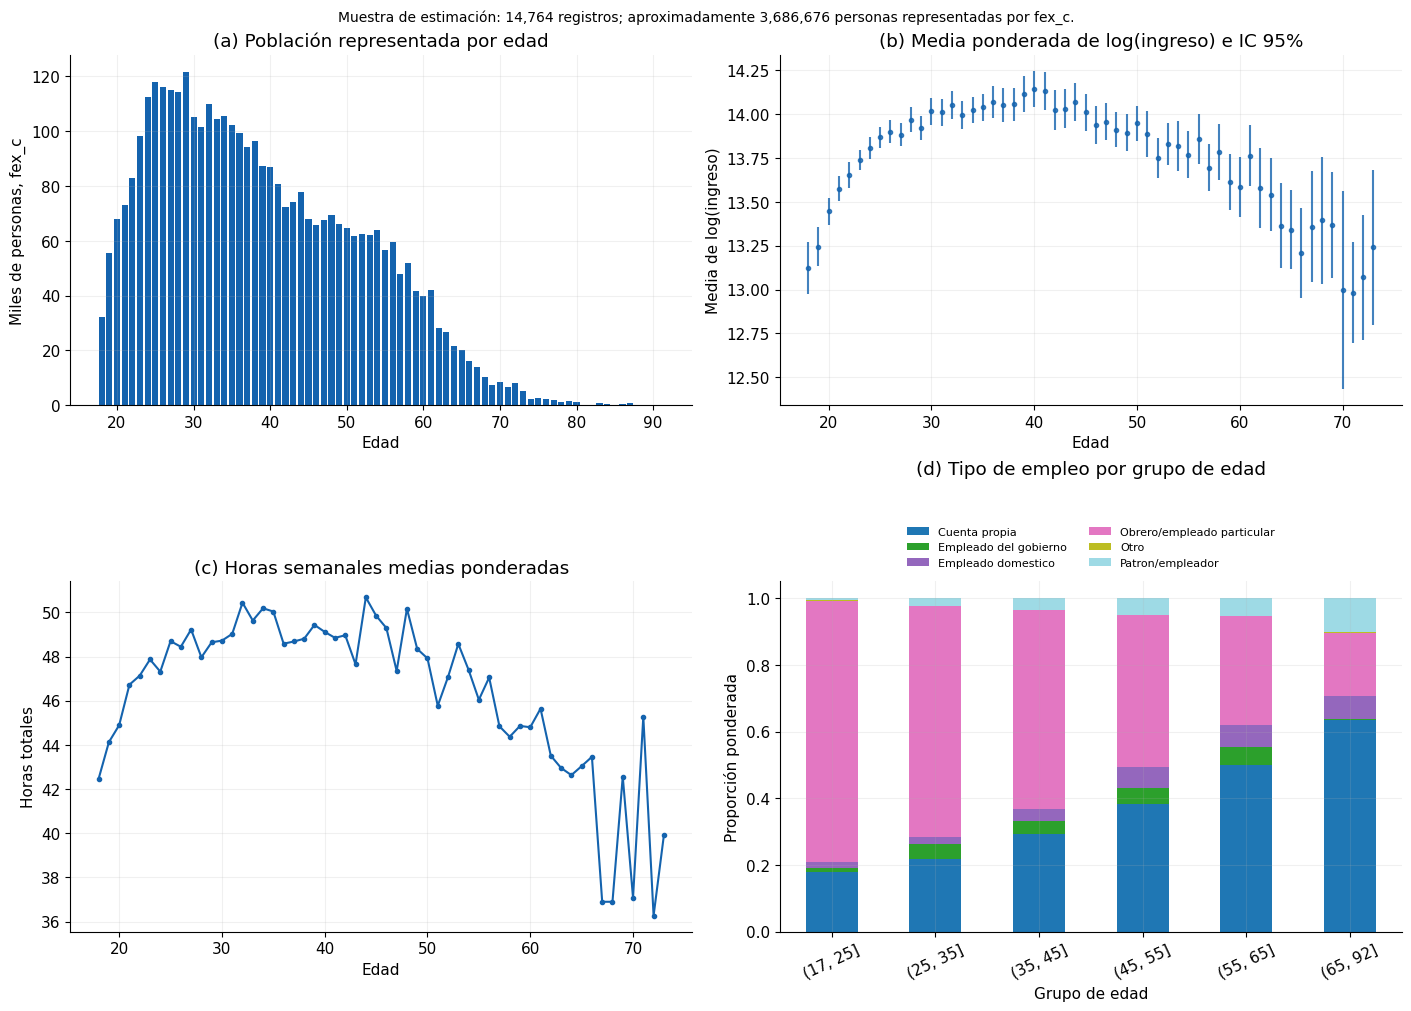

In [35]:
medias=a.descriptivas(m)

## 3. Perfil incondicional: coeficientes, ajuste y pico
El efecto marginal asociativo en log-puntos es $\hat\beta_1+2\hat\beta_2a$. Un máximo interior requiere $\hat\beta_2<0$ y
$$\hat A^*=-\frac{\hat\beta_1}{2\hat\beta_2}$$
dentro del rango observado. El método delta usa
$$g=(0,-1/(2\hat\beta_2),\hat\beta_1/(2\hat\beta_2^2),0,\ldots)',\quad EE_\Delta(\hat A^*)=\sqrt{g'\hat V_wg},\quad IC_\Delta=\hat A^*\pm1.96EE_\Delta.$$
Se sigue el bootstrap no paramétrico por filas de la [clase 3 del profesor](https://github.com/ignaciomsarmiento/BDML_2026_20/blob/main/Lecture03/Lecture_03_bootstrap.ipynb): extraer $n$ índices con reemplazo, evaluar la función estadística y repetir $B$ veces. Es la lógica de `boot(data, statistic, R)` implementada con NumPy en Python. Cada fila conserva conjuntamente $(y_i,x_i,w_i)$; se remuestrea uniformemente entre registros y se vuelve a aplicar su peso dentro del ajuste. No se sortea con probabilidad proporcional a $w_i$ y después se pondera otra vez.

Con réplicas $\hat\theta_1^*,\ldots,\hat\theta_B^*$, se calculan
$$\widehat{EE}_{boot}=\sqrt{\frac{\sum_b(\hat\theta_b^*-\bar\theta^*)^2}{B-1}},\qquad IC_{95\%,perc}=[q_{.025}(\hat\theta^*),q_{.975}(\hat\theta^*)].$$
La semilla es 2026. El método conserva la lógica del curso; no produce necesariamente los mismos sorteos que R aun usando la misma semilla. El intervalo percentil y el método delta se interpretan bajo la aproximación de muestreo por personas descrita arriba.

Se usan 2,000 réplicas por modelo. Se cuentan las réplicas sin curvatura negativa; solo cuando su frecuencia es despreciable es razonable interpretar el intervalo de los máximos válidos. La tabla compara ambos ajustes y conserva los coeficientes completos en CSV y LaTeX.

In [36]:
fits,boots,picos=a.estimar(m)

Ambos modelos de edad: 14,764 registros; aproximadamente 3,686,676 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

modelo,pico,EE_delta,IC_delta_inf,IC_delta_sup,IC_percentil_inf,IC_percentil_sup,EE_bootstrap,sesgo_bootstrap,replicas_sin_maximo,R2_ponderado,RMSE_ponderado,n,personas_representadas
Incondicional,40.7245,0.2779,40.1797,41.2692,40.1906,41.2749,0.2724,0.0048,0,0.0522,0.8711,14764,3686675.5556
Condicional,43.6265,0.3808,42.8801,44.3730,42.9449,44.3848,0.3775,0.0176,0,0.2272,0.7866,14764,3686675.5556


variable,coef_Incondicional,EE_HC1_Incondicional,coef_Condicional,EE_HC1_Condicional
age,0.0868,0.0040,0.0734,0.0035
age^2,-0.0011,0.0000,-0.0008,0.0000
const,12.2882,0.0743,11.9624,0.0695
relab[Cuenta propia],NaN,NaN,-0.4922,0.0175
relab[Empleado del gobierno],NaN,NaN,0.7398,0.0282
relab[Empleado domestico],NaN,NaN,-0.6972,0.0291
relab[Otro],NaN,NaN,-1.0705,0.2275
relab[Patron/empleador],NaN,NaN,0.2183,0.0469
totalHoursWorked,NaN,NaN,0.0127,0.0006
Edad pico,40.7245,NaN,43.6265,NaN


## 4. Perfil condicional y comparación de modelos
Se incorporan únicamente horas totales y tipo de vínculo laboral, conforme al enunciado:
$$y_i=\beta_0+\beta_1A_i+\beta_2A_i^2+\gamma H_i+\sum_{j\ne base}\delta_j1\{R_i=j\}+u_i.$$
La base de vínculo es empleado particular. Las categorías 8 y 9 se agrupan como Otro por su escaso soporte (una y ocho personas). El perfil condicional evalúa horas y proporciones de vínculo en sus medias ponderadas comunes:
$$\hat m_c(a)=\hat\beta_0+\hat\beta_1a+\hat\beta_2a^2+\hat\gamma\bar H_w+\sum_j\hat\delta_j\bar R_{jw}.$$
El perfil incondicional es $\hat m_0(a)=\hat\beta_0^{(0)}+\hat\beta_1^{(0)}a+\hat\beta_2^{(0)}a^2$. La figura compara ambas curvas, sin descomponer su diferencia. Las bandas son intervalos puntuales del promedio logarítmico, $\hat m(a)\pm1.96\sqrt{x(a)'\hat V_wx(a)}$, no intervalos de ingresos individuales. Los cambios del pico reflejan una comparación condicional distinta y no el efecto causal de fijar las horas.

Al mantener horas y composición del empleo en valores comunes, el pico se desplaza a una edad mayor. Las descriptivas muestran menos horas y mayor participación del trabajo por cuenta propia en edades avanzadas. Esta evidencia es compatible con que el descenso del ingreso mensual reúna diferencias de intensidad laboral y tipo de empleo, además de la asociación con edad. La comparación entre ajustes no identifica cuánto causa cada mecanismo.

Ajuste de los perfiles y bootstrap: 14,764 registros; aproximadamente 3,686,676 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

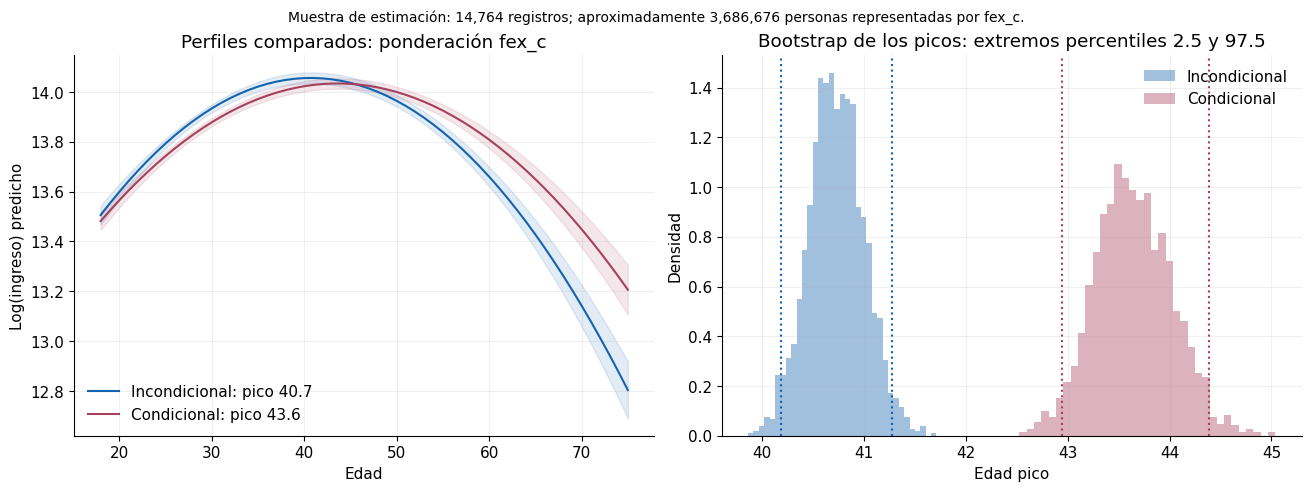

In [37]:
a.perfiles(m,fits,boots,picos)

## 5. Robustez y heterogeneidad
Para cada variante $v$ y subgrupo $G_v$ se estima
$$\hat\theta_v=\arg\min_\theta\sum_{i\in G_v}\omega_{iv}\left[y_{iv}-\alpha_v-\beta_{1v}A_i-\beta_{2v}A_i^2-Z_i'\gamma_v\right]^2.$$
La referencia usa $\omega_{iv}=\texttt{fex\_c}_i$, $y_{iv}=\log(y_{total,m,i})$ y $Z_i$ vacío. La comparación sin ponderar fija $\omega_{iv}=1$ para mostrar cuánto depende el resultado de representar la población frente a describir las filas observadas. La variante sin extremos excluye la unión de las alertas de ingreso por hora bajo, ingreso mensual alto, horas excesivas y marca extrema DANE definidas en el cuaderno de datos. La de ingreso por hora usa $y_{iv}=\log\{y_{total,m,i}/(H_i\,30/7)\}$; cambia la variable dependiente y no equivale a controlar por horas. La variante condicional usa solamente horas y vínculo en $Z_i$.

El panel (a) reporta $\hat A_v^*=-\hat\beta_{1v}/(2\hat\beta_{2v})$ y su IC 95% delta HC1. Los paneles (b) y (c) estiman por separado en educación y sexo la parábola incondicional ponderada y dibujan $\hat\alpha_v+\hat\beta_{1v}a+\hat\beta_{2v}a^2$, con bandas puntuales HC1. Son comparaciones de grupos, no efectos causales de pertenecer a ellos.

La tabla informa la población representada en cada variante. En la estimación sin pesos ese campo queda no aplicable: el estimador describe las filas, aunque sus registros provengan de la misma fuente. La población de cada subgrupo se calcula antes del ajuste, sin sumar ni promediar las expansiones de las réplicas bootstrap.

Referencia de robustez; cada variante tiene su propio total en la tabla: 14,764 registros; aproximadamente 3,686,676 personas representadas por fex_c. IC del total: no disponible con el diseño suministrado.

variante,n,personas_representadas,pico,IC_inf,IC_sup,curvatura,R2
"Incondicional, fex_c",14764,3686675.5556,40.7245,40.1797,41.2692,-0.0011,0.0522
"Incondicional, sin pesos",14764,NaN,40.6178,40.0645,41.1711,-0.0010,0.0500
"Sin extremos, fex_c",14209,3542560.2641,40.9868,40.4315,41.5421,-0.0010,0.0499
"Ingreso por hora, fex_c",14764,3686675.5556,42.2180,41.4145,43.0214,-0.0007,0.0256
"Condicional, fex_c",14764,3686675.5556,43.6265,42.8801,44.3730,-0.0008,0.2272
Hombres,7775,1958139.9107,43.5337,42.7425,44.3250,-0.0010,0.0662
Mujeres,6989,1728535.6449,37.7308,36.9513,38.5102,-0.0012,0.0673
Sin terciaria,8649,2183348.5740,37.4328,36.4355,38.4302,-0.0007,0.0586
Con terciaria,6114,1503057.1683,48.3991,46.6385,50.1597,-0.0013,0.1128
Formales,8894,2219300.1728,43.6104,42.5546,44.6662,-0.0010,0.0516


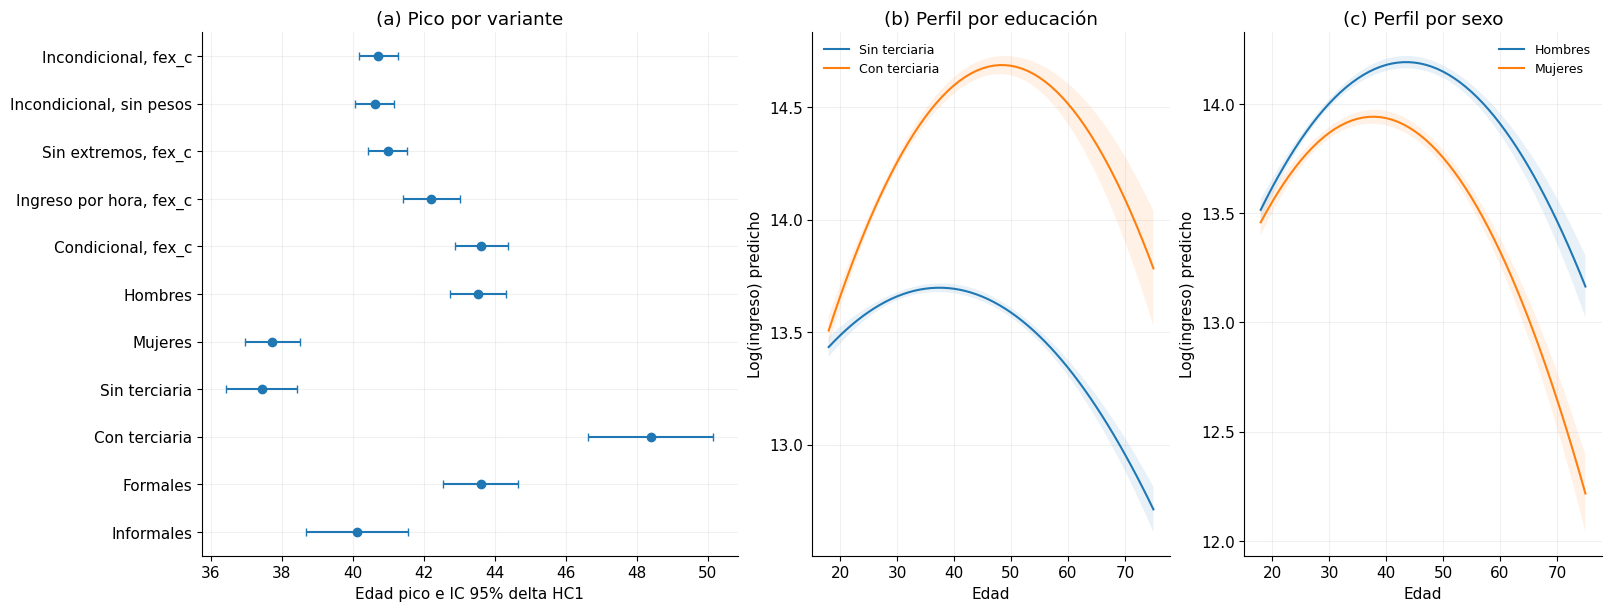

In [38]:
robustez=a.robustez(m)

## 6. Pregunta Dian

tipo,variable,coef_Condicional,brecha_porcentual_cat_ref
cat_referencia,Relab[Empleado Particular],-,0.0000
cat,relab[Cuenta propia],-0.4922,-38.8736
cat,relab[Empleado del gobierno],0.7398,109.5580
cat,relab[Empleado domestico],-0.6972,-50.2027
cat,relab[Otro],-1.0705,-65.7159
cat,relab[Patron/empleador],0.2183,24.3950


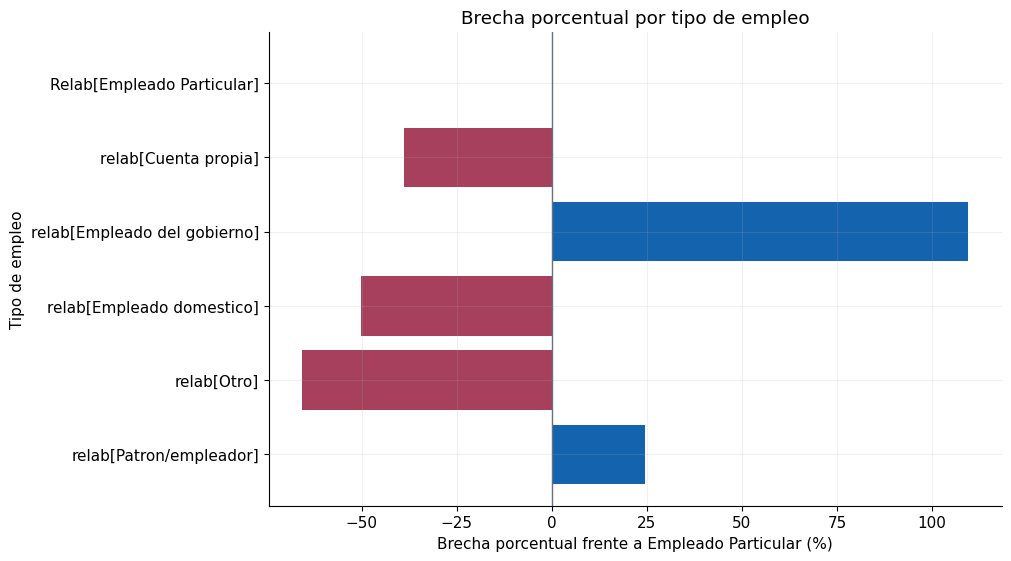

Interpreta las categorías de relab del modelo condicional. La brecha porcentual se calcula respecto a la categoría de referencia mediante: 100 * (exp(beta) - 1)

In [41]:
a.interpretar(m)
display(Markdown('''Interpreta las categorías de relab del modelo condicional. La brecha porcentual se calcula respecto a la categoría de referencia mediante: 100 * (exp(beta) - 1)'''))

## 7. Conclusiones

In [42]:
r0,r1=picos.iloc[0],picos.iloc[1]
display(Markdown(f'''El pico ponderado es {r0.pico:.2f} años en el perfil incondicional, con IC percentil [{r0.IC_percentil_inf:.2f}, {r0.IC_percentil_sup:.2f}], y {r1.pico:.2f} años al controlar horas y vínculo, con IC [{r1.IC_percentil_inf:.2f}, {r1.IC_percentil_sup:.2f}]. El ajuste ponderado pasa de R²={r0.R2_ponderado:.3f} a {r1.R2_ponderado:.3f}.

La concavidad es compatible con capital humano, pero el pico depende de la forma cuadrática y de la población observada. La precisión de una curva promedio no asegura predicciones individuales precisas. La ponderación representa la población cubierta de Bogotá; no corrige por sí sola la selección por ingreso faltante ni identifica envejecimiento causal.

El perfil de mayor interés para la DIAN se sitúa en personas entre 42,9 y 44,4 años, que sean empleados particulares, empleados del gobierno o empleadores 
'''))

El pico ponderado es 40.72 años en el perfil incondicional, con IC percentil [40.19, 41.27], y 43.63 años al controlar horas y vínculo, con IC [42.94, 44.38]. El ajuste ponderado pasa de R²=0.052 a 0.227.

La concavidad es compatible con capital humano, pero el pico depende de la forma cuadrática y de la población observada. La precisión de una curva promedio no asegura predicciones individuales precisas. La ponderación representa la población cubierta de Bogotá; no corrige por sí sola la selección por ingreso faltante ni identifica envejecimiento causal.

El perfil de mayor interés para la DIAN se sitúa en personas entre 42,9 y 44,4 años, que sean empleados particulares, empleados del gobierno o empleadores 
